# Day 9: Loss Functions & Activation Functions

> **Goal:** Understand the most common loss functions and activation functions, know when to use each, and see them in action on a small classification task.

---

## Why These Matter

- **Loss function** = "How wrong is the model?" — it's the number the optimizer *minimises*.
- **Activation function** = "How does a neuron transform its input?" — without activations, stacking linear layers is still just linear.

Choosing the right pair is critical to getting your network to learn.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

---
## Part A: Activation Functions

### Why do we need them?

A linear layer computes `y = Wx + b`. Stacking two linear layers gives `y = W2(W1x + b1) + b2 = W2W1x + ...`, which is still linear! **Non-linear activations** let networks learn curved, complex decision boundaries.

### The Big Four

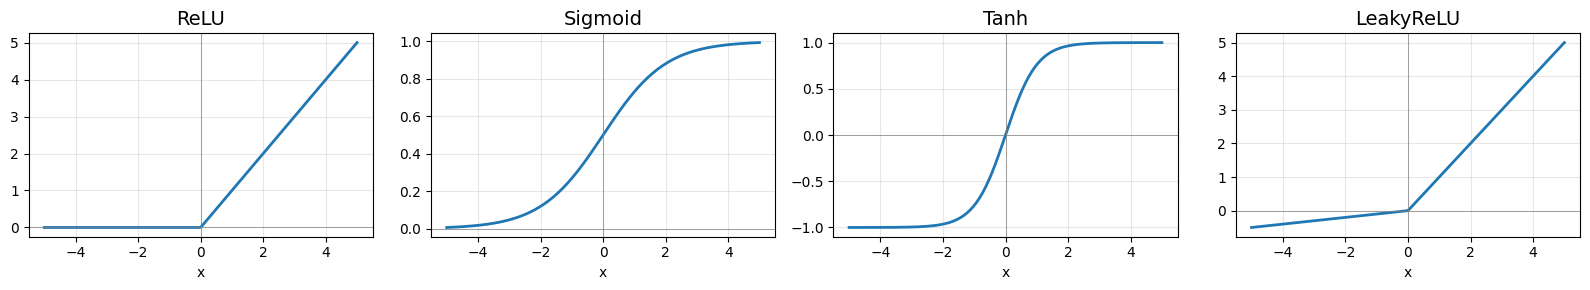

In [4]:
x = torch.linspace(-5, 5, 200)

activations = {
    "ReLU":    torch.relu(x),
    "Sigmoid": torch.sigmoid(x),
    "Tanh":    torch.tanh(x),
    "LeakyReLU": F.leaky_relu(x, negative_slope=0.1),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x.numpy(), y.numpy(), linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Quick Reference

| Activation | Formula | Range | When to use |
|---|---|---|---|
| **ReLU** | `max(0, x)` | [0, ∞) | Default for hidden layers |
| **Sigmoid** | `1 / (1 + e^(-x))` | (0, 1) | Output layer for binary classification |
| **Tanh** | `(e^x - e^(-x)) / (e^x + e^(-x))` | (-1, 1) | Hidden layers (centered around 0) |
| **LeakyReLU** | `max(αx, x)` | (-∞, ∞) | Avoids "dead neurons" problem of ReLU |

### Softmax — for multi-class output

Softmax converts a vector of raw scores ("logits") into probabilities that sum to 1.

In [5]:
logits = torch.tensor([2.0, 1.0, 0.5])
probs = F.softmax(logits, dim=0)

print(f"Logits:        {logits.tolist()}")
print(f"Probabilities: {probs.tolist()}")
print(f"Sum:           {probs.sum().item():.4f}")

Logits:        [2.0, 1.0, 0.5]
Probabilities: [0.6285316944122314, 0.23122389614582062, 0.14024437963962555]
Sum:           1.0000


---
## Part B: Loss Functions

### 1. Mean Squared Error (MSE) — for regression

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Use when your target is a **continuous number** (e.g., predicting temperature, intensity).

In [6]:
y_true = torch.tensor([1.0, 2.0, 3.0])
y_pred = torch.tensor([1.1, 2.5, 2.8])

# Manual
mse_manual = ((y_true - y_pred) ** 2).mean()

# PyTorch
mse_fn = nn.MSELoss()
mse_pytorch = mse_fn(y_pred, y_true)

print(f"MSE (manual):  {mse_manual.item():.4f}")
print(f"MSE (PyTorch): {mse_pytorch.item():.4f}")

MSE (manual):  0.1000
MSE (PyTorch): 0.1000


### 2. Binary Cross-Entropy (BCE) — for binary classification

$$\text{BCE} = -\frac{1}{N} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

Use when your target is **0 or 1** (e.g., defective / not defective).

**Important:** `nn.BCELoss` expects *probabilities* (after sigmoid). `nn.BCEWithLogitsLoss` applies sigmoid internally and is more numerically stable.

In [7]:
# Target: 0 or 1
targets = torch.tensor([1.0, 0.0, 1.0])

# Model outputs raw scores (logits)
logits = torch.tensor([2.0, -1.0, 0.5])

# Method 1: BCEWithLogitsLoss (preferred — handles sigmoid internally)
bce_logits_fn = nn.BCEWithLogitsLoss()
loss1 = bce_logits_fn(logits, targets)

# Method 2: Sigmoid + BCELoss (equivalent but less stable)
probs = torch.sigmoid(logits)
bce_fn = nn.BCELoss()
loss2 = bce_fn(probs, targets)

print(f"BCEWithLogitsLoss: {loss1.item():.4f}")
print(f"Sigmoid + BCELoss: {loss2.item():.4f}")
print(f"Equal? {torch.allclose(loss1, loss2)}")

BCEWithLogitsLoss: 0.3048
Sigmoid + BCELoss: 0.3048
Equal? True


### 3. Cross-Entropy Loss — for multi-class classification

$$\text{CE} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

Use when you have **>2 classes** (e.g., classifying digits 0–9).

**Important:** `nn.CrossEntropyLoss` expects:
- **Input:** raw logits (NOT softmax output)
- **Target:** class indices (integers), not one-hot vectors

In [9]:
# 3 classes, batch of 4 samples
logits = torch.randn(4, 3)                    # raw scores
targets = torch.tensor([0, 2, 1, 0])           # class indices

ce_fn = nn.CrossEntropyLoss()
loss = ce_fn(logits, targets)

print(f"Logits:\n{logits}")
print(f"\nTargets: {targets}")
print(f"\nCross-Entropy Loss: {loss.item():.4f}")

# What CrossEntropyLoss does internally:
manual = F.log_softmax(logits, dim=1)  # log of probabilities
manual_loss = F.nll_loss(manual, targets)  # negative log likelihood
print(f"Manual CE Loss:     {manual_loss.item():.4f}")
print(manual.shape)

Logits:
tensor([[ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950]])

Targets: tensor([0, 2, 1, 0])

Cross-Entropy Loss: 1.1832
Manual CE Loss:     1.1832
torch.Size([4, 3])


### Summary: Which Loss to Use?

| Task | Loss Function | Output activation |
|---|---|---|
| Regression | `nn.MSELoss()` | None (raw output) |
| Binary classification | `nn.BCEWithLogitsLoss()` | None (sigmoid built in) |
| Multi-class classification | `nn.CrossEntropyLoss()` | None (softmax built in) |

---
## Part C: Putting It Together — Classify Toy Data

Let's create a 2D dataset with 3 classes and train a small network to classify it.

torch.Size([300, 2])
torch.Size([300])


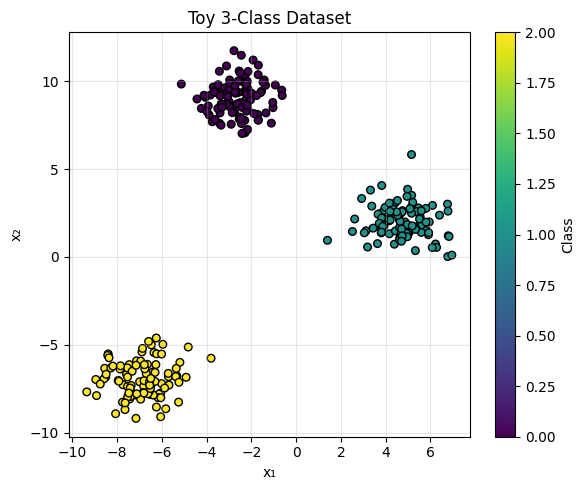

In [11]:
from sklearn.datasets import make_blobs

# Generate 3 clusters in 2D
X_np, y_np = make_blobs(n_samples=300, centers=3, n_features=2,
                        cluster_std=1.0, random_state=42)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

print(X.shape)
print(y.shape)

# Visualize
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k", s=30)
plt.colorbar(scatter, label="Class")
plt.title("Toy 3-Class Dataset")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Building and Training the Classifier

We'll build a small 3-layer network with ReLU activations and train it with `CrossEntropyLoss`. Notice that the output layer has **3 neurons** (one per class) and outputs **raw logits** — `CrossEntropyLoss` handles the softmax internally.

In [15]:
# Build a classifier
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 3),  # 3 classes → 3 output logits
        )

    def forward(self, x):
        return self.net(x)  # return raw logits


model = Classifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
losses = []
for epoch in range(200):
    logits = model(X)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 40 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
        print(f"Epoch {epoch:3d}  Loss: {loss.item():.4f}  Acc: {acc.item():.2%}")

print(f"\nFinal accuracy: {(model(X).argmax(1) == y).float().mean():.2%}")

Epoch   0  Loss: 1.2527  Acc: 58.33%
Epoch  40  Loss: 0.0006  Acc: 100.00%
Epoch  80  Loss: 0.0003  Acc: 100.00%
Epoch 120  Loss: 0.0003  Acc: 100.00%
Epoch 160  Loss: 0.0002  Acc: 100.00%

Final accuracy: 100.00%


### Visualizing Decision Boundaries

The decision boundary plot shows how the model partitions the 2D input space into three colored regions. Each point in the plane is classified by the model, and the background color shows the predicted class. A well-trained model will have smooth boundaries that cleanly separate the three clusters.

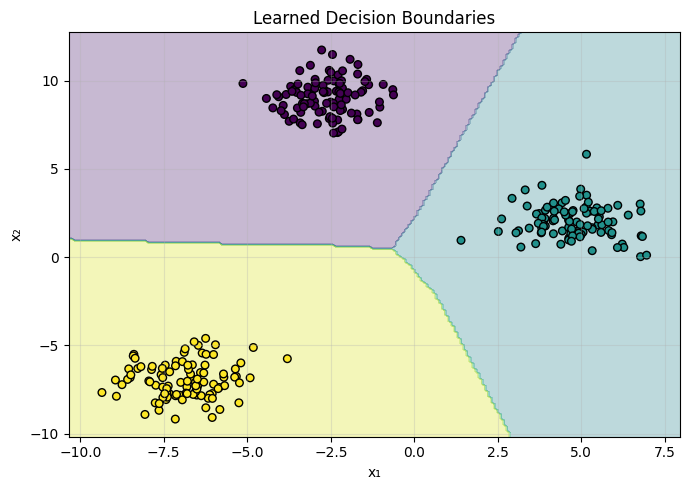

In [16]:
# Visualize decision boundaries
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        preds = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap="viridis")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k", s=30)
    plt.title("Learned Decision Boundaries")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_decision_boundary(model, X.numpy(), y.numpy())

---
## 🧪 Exercises

### Exercise 1: Visualize activation gradients
Plot the **derivative** of ReLU, Sigmoid, and Tanh. Which saturates? What does saturation mean for gradient flow?

### Exercise 2: Binary classifier
Create a 2-class dataset with `make_blobs(centers=2)`. Build a network that outputs 1 logit, use `BCEWithLogitsLoss`, and plot the decision boundary.

### Exercise 3: Effect of wrong loss
Try using `MSELoss` instead of `CrossEntropyLoss` on the 3-class problem above. Does it still learn? How well?

### Exercise 4: Temperature scaling
Divide logits by a temperature T before softmax: `softmax(logits / T)`. Try T = 0.1, 1.0, 10.0. What happens to the probability distribution?

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **ReLU** | Default hidden activation — simple, effective, can cause dead neurons |
| **Sigmoid** | Output for binary classification — squashes to (0,1) |
| **Softmax** | Output for multi-class — produces probability distribution |
| **MSELoss** | Regression tasks |
| **BCEWithLogitsLoss** | Binary classification (sigmoid + BCE combined) |
| **CrossEntropyLoss** | Multi-class classification (softmax + NLL combined) |
| **Don't apply softmax/sigmoid before CE/BCE loss** | The loss functions include it internally for numerical stability |

**Tomorrow:** We'll load real image data (MNIST) using `Dataset` and `DataLoader` — the gateway to training on actual data!